In [1]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Загрузка данных

Датасет содержит статистику выбора героев Dota 2 в профессиональных матчах:
- **Name** — имя героя
- **Primary Attribute** — основной атрибут (all / str / agi / int)
- **Attack Type** — тип атаки (Melee / Ranged)
- **Attack Range** — дальность атаки
- **Roles** — роли героя
- **Total Pro wins** — количество побед в профессиональных матчах
- **Times Picked** — количество пиков
- **Times Banned** — количество банов
- **Win Rate** — процент побед
- **Niche Hero?** — является ли герой нишевым

**Целевая переменная**:  (4 класса: all, str, agi, int)

In [2]:
# Загружаем датасет из CSV-файла

dataset = pd.read_csv('/content/dota2HeroPick.csv', index_col=0)

# Анализ данных

In [3]:
# Размер датасета: 124 героя, 10 столбцов

dataset.shape

(124, 10)

In [4]:
# Отображаем первые 10 строк датасета

dataset.head(10)

,Name,Primary Attribute,Attack Type,Attack Range,Roles,Total Pro wins,Times Picked,Times Banned,Win Rate,Niche Hero?
0,Abaddon,all,Melee,150,"Support, Carry, Durable",8,24,61,33.33,False
1,Alchemist,str,Melee,150,"Carry, Support, Durable, Disabler, Initiator, ...",23,55,22,41.82,False
2,Ancient Apparition,int,Ranged,675,"Support, Disabler, Nuker",40,77,73,51.95,False
3,Anti-Mage,agi,Melee,150,"Carry, Escape, Nuker",40,66,78,60.61,False
4,Arc Warden,agi,Ranged,625,"Carry, Escape, Nuker",5,14,31,35.71,False
5,Axe,str,Melee,150,"Initiator, Durable, Disabler, Carry",122,262,222,46.56,False
6,Bane,all,Ranged,400,"Support, Disabler, Nuker, Durable",84,152,104,55.26,True
7,Batrider,all,Ranged,400,"Initiator, Disabler, Escape",19,54,105,35.19,False
8,Beastmaster,all,Melee,150,"Initiator, Disabler, Durable, Nuker",170,333,484,51.05,False
9,Bloodseeker,agi,Melee,150,"Carry, Disabler, Nuker, Initiator",70,157,461,44.59,False


In [5]:
# Метод info() — информация о типах данных и пропущенных значениях

dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 124 entries, 0 to 123
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               124 non-null    object 
 1   Primary Attribute  124 non-null    object 
 2   Attack Type        124 non-null    object 
 3   Attack Range       124 non-null    int64  
 4   Roles              124 non-null    object 
 5   Total Pro wins     124 non-null    int64  
 6   Times Picked       124 non-null    int64  
 7   Times Banned       124 non-null    int64  
 8   Win Rate           124 non-null    float64
 9   Niche Hero?        124 non-null    bool   
dtypes: bool(1), float64(1), int64(4), object(4)
memory usage: 9.8+ KB


In [6]:
# describe() — основная статистика по числовым столбцам

dataset.describe()

,Attack Range,Total Pro wins,Times Picked,Times Banned,Win Rate
count,124.000000,124.000000,124.000000,124.000000,124.000000
mean,350.604839,91.975806,183.951613,255.112903,49.390726
std,200.271759,73.328691,143.145492,241.567349,6.317535
min,150.000000,4.000000,5.000000,18.000000,32.730000
25%,150.000000,40.750000,82.500000,80.000000,46.217500
50%,340.000000,79.000000,156.000000,185.500000,50.250000
75%,550.000000,106.000000,215.250000,325.000000,52.492500
max,700.000000,407.000000,801.000000,1049.000000,80.000000


In [7]:
# Уникальные классы целевой переменной Primary Attribute

dataset['Primary Attribute'].unique()

array(['all', 'str', 'int', 'agi'], dtype=object)

In [8]:
# Количество героев в каждом классе

dataset['Primary Attribute'].value_counts()

,count
Primary Attribute,
all,32
str,31
agi,31
int,30


Видим, что набор данных сбалансированный: классы , , ,  имеют примерно одинаковое количество записей (~30 каждый).

# Визуализация данных

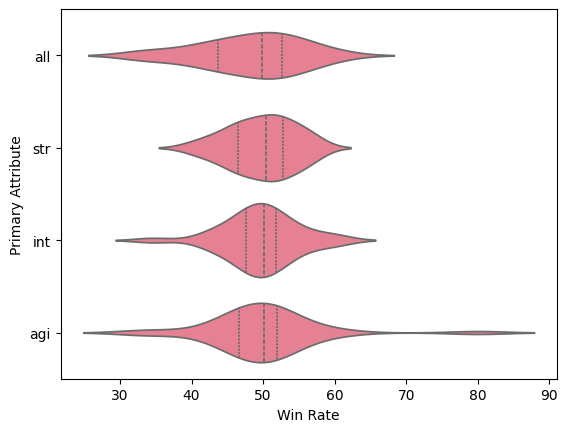

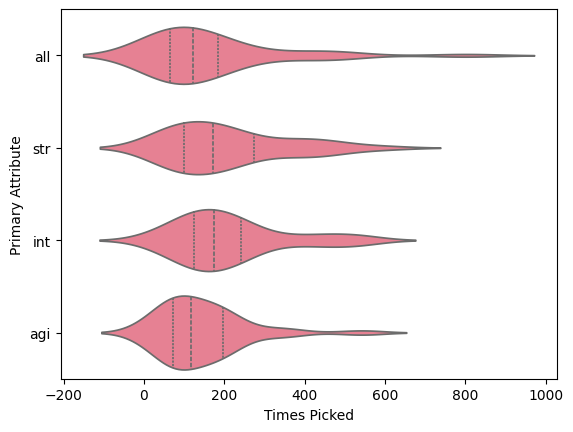

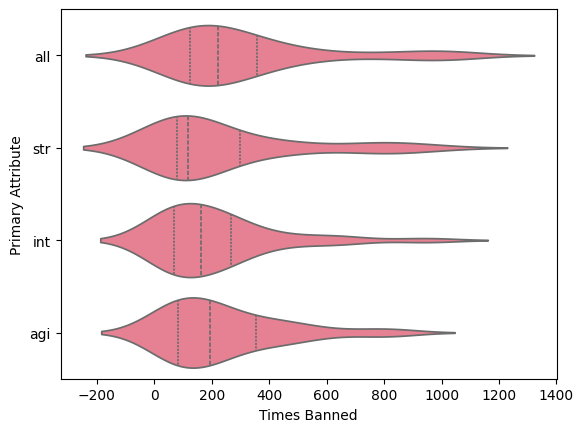

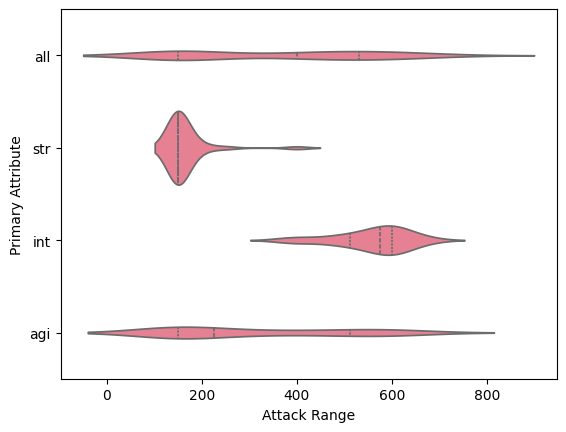

In [9]:
# Скрипичный график.
# Используется для проверки сравнения распределения переменных по классам Primary Attribute:

sns.violinplot(y='Primary Attribute', x='Win Rate', data=dataset, inner='quartile')
plt.show()
sns.violinplot(y='Primary Attribute', x='Times Picked', data=dataset, inner='quartile')
plt.show()
sns.violinplot(y='Primary Attribute', x='Times Banned', data=dataset, inner='quartile')
plt.show()
sns.violinplot(y='Primary Attribute', x='Attack Range', data=dataset, inner='quartile')
plt.show()

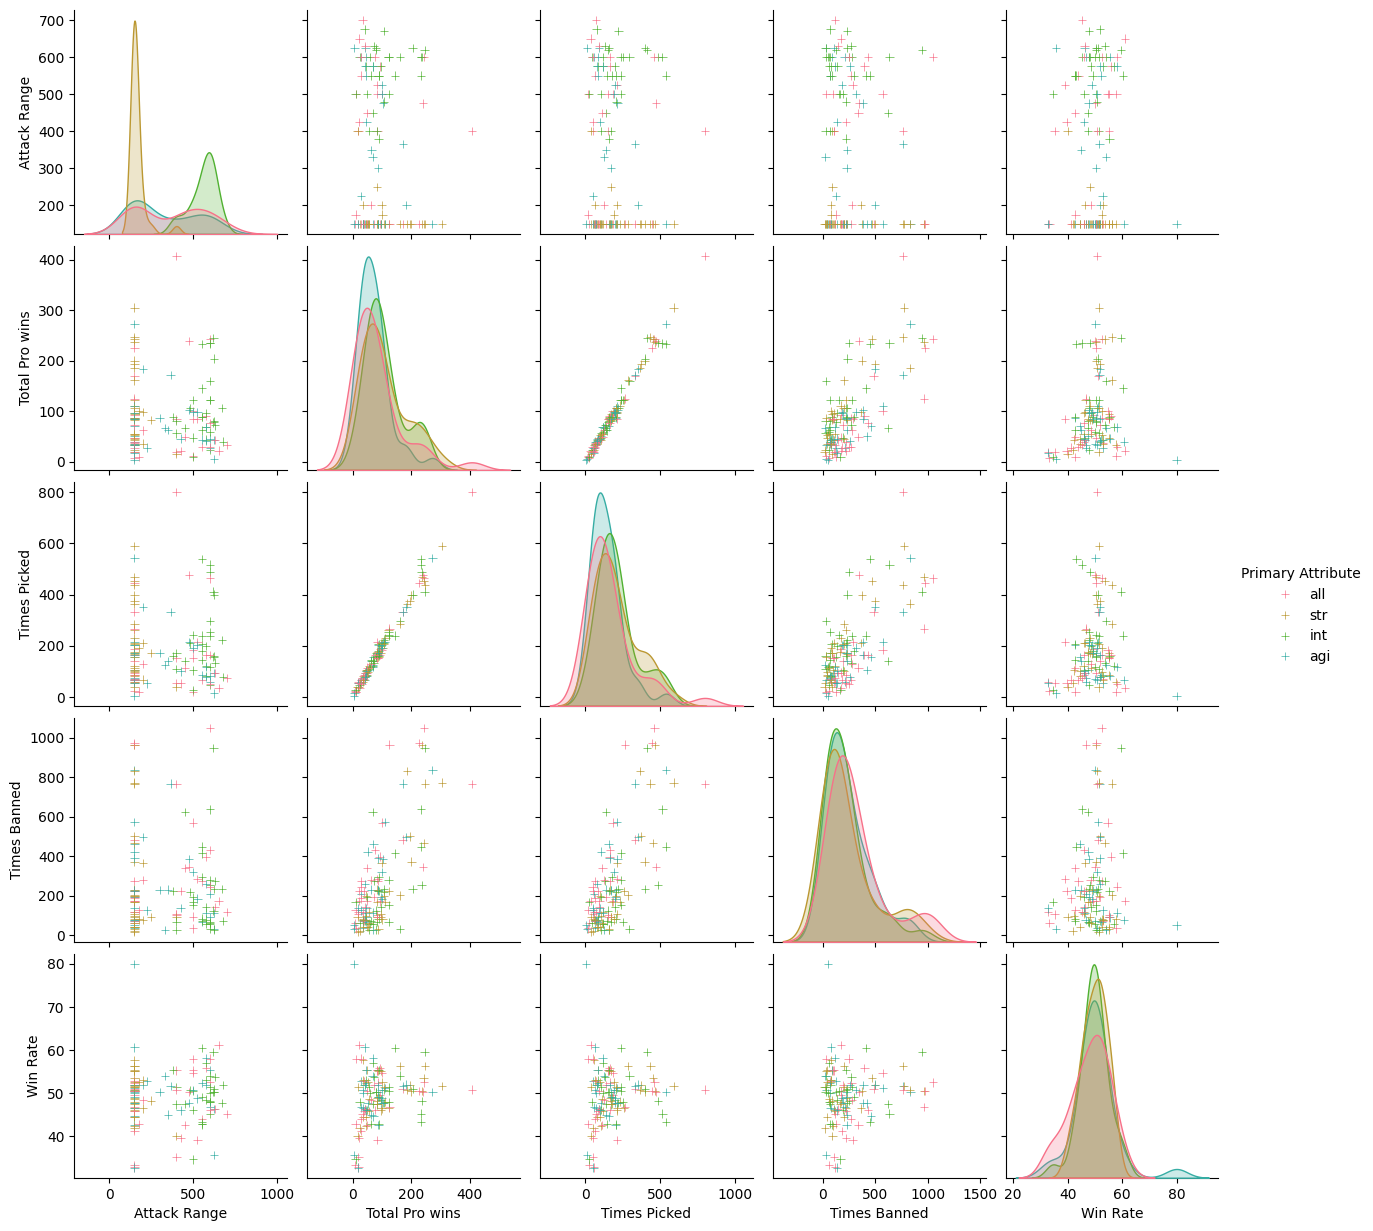

In [10]:
# Парный график
# Построение попарных двумерных распределений в наборе данных:

numeric_cols = ['Attack Range', 'Total Pro wins', 'Times Picked', 'Times Banned', 'Win Rate']
sns.pairplot(dataset[numeric_cols + ['Primary Attribute']], hue='Primary Attribute', markers='+')
plt.show()

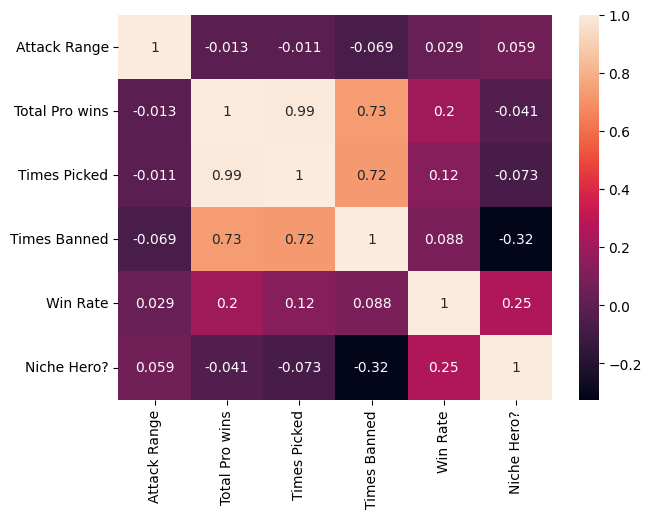

In [11]:
# Тепловая карта
# Построение тепловой карты для проверки корреляции числовых признаков:

plt.figure(figsize=(7, 5))
sns.heatmap(dataset.corr(numeric_only=True), annot=True)
plt.show()

# Построение модели

## Разделение набора данных

**Y** — целевая переменная  (4 класса: all, str, agi, int).

**X** — числовые признаки: , , , , .

Категориальные столбцы (, , , ) на данном этапе не используются.

In [12]:
feature_cols = ['Attack Range', 'Total Pro wins', 'Times Picked', 'Times Banned', 'Win Rate']

X = dataset[feature_cols]
y = dataset['Primary Attribute']
print(f'X shape: {X.shape} | y shape: {y.shape}')

X shape: (124, 5) | y shape: (124,)


## Train/Test разделение

Разбиваем данные на обучающую (80%) и тестовую (20%) выборки.
Используем , чтобы сохранить пропорции классов в обеих частях.

In [13]:
import scipy.stats as stats

# Кодируем целевую переменную в числа
label_map = {'all': 0, 'str': 1, 'agi': 2, 'int': 3}
y_mapped = y.map(label_map)

# Разбиение с перемешиванием (без stratify) — проверяем, что выборки статистически схожи
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.30, shuffle=True)

stats.ttest_ind(a=y_train, b=y_test)

TtestResult(statistic=np.float64(0.013940047425623155), pvalue=np.float64(0.9889005823285879), df=np.float64(122.0))

In [14]:
# Разбиение со стратификацией (рекомендуется) — классы сбалансированы в train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_mapped, test_size=0.20, random_state=15, stratify=y_mapped
)

stats.ttest_ind(a=y_train, b=y_test)

TtestResult(statistic=np.float64(0.17782654209391435), pvalue=np.float64(0.8591541266534297), df=np.float64(122.0))

## Обучение и выбор оптимальной модели

Протестируем следующие алгоритмы:

- Logistic Regression (LR)
- Linear Discriminant Analysis (LDA)
- K-Nearest Neighbors (KNN)
- Decision Tree (CART)
- Gaussian Naive Bayes (NB)
- Support Vector Machines (SVC)

In [15]:
# Создаём список моделей
models = []
models.append(('LR',   LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA',  LinearDiscriminantAnalysis()))
models.append(('KNN',  KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB',   GaussianNB()))
models.append(('SVC',  SVC(gamma='auto')))

# Оцениваем метрики с помощью кросс-валидации
results = []
model_names = []
for name, model in models:
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    model_names.append(name)
    print('%s: %.4f (±%.4f)' % (name, cv_results.mean(), cv_results.std()))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

LR: 0.5244 (±0.1213)
LDA: 0.5044 (±0.0964)
KNN: 0.5244 (±0.1368)
CART: 0.4333 (±0.2082)
NB: 0.4333 (±0.0730)
SVC: 0.1811 (±0.0379)


## Обучение конкретной модели

По результатам кросс-валидации выбираем наилучший алгоритм — LinearDiscriminantAnalysis.

1. Обучаем LDA на  /
2. Делаем прогноз на
3. Смотрим точность

In [19]:
sk_lda = LinearDiscriminantAnalysis(solver='eigen')
sk_lda.fit(X_train, y_train)
sk_lda_pred_res = sk_lda.predict(X_test)
sk_transformed = sk_lda.transform(X_train)
sk_lda_accuracy = accuracy_score(y_test, sk_lda_pred_res)

print(f'sk LDA accuracy: {sk_lda_accuracy:.4f}')
print(f'Predictions: {sk_lda_pred_res}')
print('Transformed features (first 5):', sk_transformed[:5].T)

sk LDA accuracy: 0.4000
Predictions: [0 1 1 1 1 1 3 0 1 3 3 2 3 1 3 0 1 0 0 2 1 3 0 3 3]
Transformed features (first 5): [[ -4.33852473  -4.24393358  -5.0336002   -1.62674177  -1.89636947]
 [ -1.5522987   -0.52813859  -0.40250446   0.7180064   -0.26259488]
 [ -9.33384258  -9.81563694  -9.99309658 -10.18610909  -9.8831045 ]]


## Визуализация решения

/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


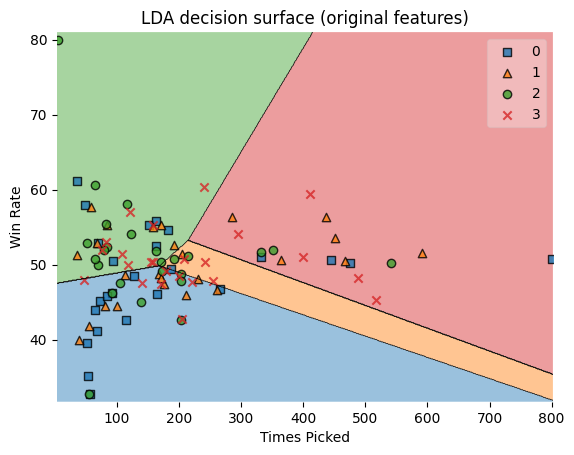

In [20]:
from mlxtend.plotting import plot_decision_regions

# Для 2D-визуализации берём два наиболее информативных числовых признака
y_s = y_train
X_2d = X_train[['Times Picked', 'Win Rate']].values
y_2d = y_s.values

sk_lda1 = LinearDiscriminantAnalysis(solver='eigen')
sk_lda1.fit(X_2d, y_2d)

plt.title('LDA decision surface (original features)')
plot_decision_regions(X=X_2d, y=y_2d, clf=sk_lda1)
plt.xlabel('Times Picked')
plt.ylabel('Win Rate')
plt.show()

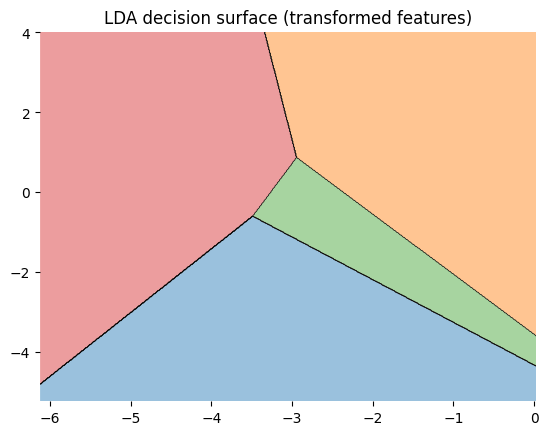

In [23]:
y_all = y_mapped.values

X_2d_all = dataset[['Times Picked', 'Win Rate']].values

sk_lda2 = LinearDiscriminantAnalysis(solver='eigen')
X1_lda = sk_lda2.fit(X[feature_cols].values, y_all).transform(X[feature_cols].values)

X1_lda_train, X1_lda_test, y1_train, y1_test = train_test_split(X1_lda, y_all, random_state=0)

sk_lda2.fit(X1_lda_train, y1_train)

plt.title('LDA decision surface (transformed features)')
plot_decision_regions(X=X1_lda, y=y_all, clf=sk_lda2, feature_index=[0, 1], filler_feature_values={2: X1_lda[:, 2].mean()})
plt.show()

In [24]:
predicted = sk_lda2.predict(X1_lda_test)

In [26]:
from sklearn import metrics

# Метрики на тестовой выборке
accuracy = metrics.accuracy_score(y1_test, predicted)

recall    = metrics.recall_score(y1_test, predicted, average="weighted")
precision = metrics.precision_score(y1_test, predicted, average="weighted")

print("Accuracy:", round(accuracy, 4))
print("Recall   (weighted):", round(recall, 2))
print("Precision (weighted):", round(precision, 2))
print("Detailed report:")
target_names = [k for k, v in sorted(label_map.items(), key=lambda x: x[1])]
print(metrics.classification_report(y1_test, predicted, target_names=target_names))

Accuracy: 0.5806
Recall   (weighted): 0.58
Precision (weighted): 0.59
Detailed report:
              precision    recall  f1-score   support

         all       0.50      0.12      0.20         8
         str       0.36      0.67      0.47         6
         agi       0.67      0.33      0.44         6
         int       0.73      1.00      0.85        11

    accuracy                           0.58        31
   macro avg       0.57      0.53      0.49        31
weighted avg       0.59      0.58      0.53        31

